1.   First Dataset : - MLP/Tabnet/cnn/Ft-transformer
2.   Second One :cnn/Ft-transfomer

# Model 1 – Hybrid 1D-CNN + Residual + Self-Attention
## Model 2 – FT-Transformer (Feature Tokenizer + Deep Transformer)

In [ ]:
!pip install pytorch-tabnet -q

import pandas as pd
import numpy as np
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import warnings
warnings.filterwarnings("ignore")

print("TabNet ready! (State-of-the-art for tabular medical data)")
warnings.filterwarnings("ignore")

train = pd.read_csv('/content/train_FINAL.csv')
val   = pd.read_csv('/content/val_FINAL.csv')
test  = pd.read_csv('/content/test_FINAL.csv')

print("Shapes:")
print("Train:", train.shape)
print("Val:  ", val.shape)
print("Test: ", test.shape)

display(train.head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.4 MB/s eta 0:00:00
TabNet ready! (State-of-the-art for tabular medical data)
Shapes:
Train: (5037, 17)
Val:   (1079, 17)
Test:  (1080, 17)


,Gender,Age,HGB,RBC,WBC,PLT,LYMP,MONO,HCT,MCV,MCH,MCHC,RDW,PDW,MPV,PCT,label
0,-1.037841,0.054783,-0.298952,1.930864,-0.129311,0.101881,-0.455000,-0.351770,0.349003,-1.603926,-1.658739,-0.891947,-2.064585,-0.933900,-1.158386,-0.756801,2
1,-1.037841,1.494908,0.223456,-0.019865,-0.689246,2.123287,0.354313,-0.658370,0.717942,1.305956,1.100072,-0.231026,-1.343124,0.276686,1.161722,1.157404,13
2,-1.037841,-0.825293,-0.781176,-0.680946,-0.150994,-0.121891,-0.985240,-0.422524,-0.595481,0.556170,0.613223,0.429895,-0.802028,-0.242137,1.372640,1.157404,0
3,0.963539,-0.105230,0.344012,0.175208,-0.636951,-0.785748,-0.929425,-0.186678,0.570366,0.761469,0.991884,0.892540,-0.501419,-0.242137,1.161722,1.157404,9
4,0.963539,-0.025224,-0.178396,0.229395,-0.792560,-0.024923,1.247348,-0.186678,0.142397,0.074166,0.099327,0.297711,-0.862150,-0.069196,0.739884,1.157404,14


In [ ]:
train_full = pd.concat([train, val], ignore_index=True)

X_train = train_full.drop('label', axis=1).values
y_train = train_full['label'].values

X_test = test.drop('label', axis=1).values
y_test = test['label'].values

# Optional: Very light scaling (TabNet is quite robust even without it)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [ ]:
# STEP 3: Create TabNet model
clf = TabNetClassifier(
    n_d=64, n_a=64,          # width of decision & attention layers (64 is sweet spot)
    n_steps=5,               # depth (5–7 works great)
    gamma=1.5,               # feature reuse
    lambda_sparse=1e-4,      # encourages feature selection
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size": 20, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='sparsemax',   # better than softmax for feature selection
    verbose=10,
    seed=42
)


In [ ]:
# STEP 4: Train (with early stopping)
clf.fit(
    X_train=X_train, y_train=y_train,
    eval_set=[(X_test, y_test)],
    eval_name=['test'],
    eval_metric=['accuracy'],
    max_epochs=200,
    patience=30,             # stop if no improvement for 30 epochs
    batch_size=1024,
    virtual_batch_size=128
)

epoch 0  | loss: 3.24116 | test_accuracy: 0.45556 |  0:00:02s
epoch 10 | loss: 0.62246 | test_accuracy: 0.80648 |  0:00:26s
epoch 20 | loss: 0.35552 | test_accuracy: 0.9     |  0:00:38s
epoch 30 | loss: 0.23392 | test_accuracy: 0.91389 |  0:00:49s
epoch 40 | loss: 0.16888 | test_accuracy: 0.93611 |  0:01:01s
epoch 50 | loss: 0.17115 | test_accuracy: 0.93796 |  0:01:13s
epoch 60 | loss: 0.14488 | test_accuracy: 0.94167 |  0:01:25s
epoch 70 | loss: 0.12987 | test_accuracy: 0.94444 |  0:01:37s
epoch 80 | loss: 0.10492 | test_accuracy: 0.9537  |  0:01:49s
epoch 90 | loss: 0.11279 | test_accuracy: 0.9463  |  0:02:01s

Early stopping occurred at epoch 96 with best_epoch = 66 and best_test_accuracy = 0.96296


In [ ]:
# STEP 5: Results
preds = clf.predict(X_test)
acc = accuracy_score(y_test, preds)
print(f"\nTabNet Test Accuracy: {acc*100:.3f}%")

print("\nClassification Report:")
print(classification_report(y_test, preds))



TabNet Test Accuracy: 96.296%

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       210
           1       0.98      0.98      0.98       174
           2       0.97      0.98      0.98        65
           3       0.88      0.93      0.90        15
           4       0.99      0.97      0.98        71
           5       0.97      0.80      0.88        35
           6       0.80      0.96      0.87        25
           7       0.97      0.97      0.97        35
           8       0.97      0.91      0.94        35
           9       0.95      0.97      0.96        62
          10       0.95      0.98      0.96       190
          11       1.00      0.75      0.86         4
          12       1.00      0.82      0.90        17
          13       0.96      0.97      0.96        93
          14       0.96      0.90      0.93        49

    accuracy                           0.96      1080
   macro avg       0.95  

In [ ]:
# Optional: Feature importance (very useful for doctors!)
importance = clf.feature_importances_
feature_names = test.drop('label', axis=1).columns
imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
print("\nTop 10 Most Important CBC Features:")
print(imp_df.sort_values('Importance', ascending=False).head(10))

# STEP 6: Save the model
clf.save_model("cbc_tabnet_best")
print("Model saved as cbc_tabnet_best.zip")


Top 10 Most Important CBC Features:
   Feature  Importance
2      HGB    0.174889
4      WBC    0.130341
6     LYMP    0.121465
12     RDW    0.107891
5      PLT    0.087086
10     MCH    0.082515
0   Gender    0.058943
11    MCHC    0.056425
7     MONO    0.049146
8      HCT    0.047100
Successfully saved model at cbc_tabnet_best.zip
Model saved as cbc_tabnet_best.zip


In [ ]:
# Load and predict on brand new patient
from pytorch_tabnet.tab_model import TabNetClassifier
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load model
loaded_clf = TabNetClassifier()
loaded_clf.load_model("cbc_tabnet_best.zip")

# Example new patient (same 16 normalized features you used before)
new_patient = np.array([[
    0.96353894, -0.42525807,  0.7056796 ,  1.432344, -0.066812,  0.781845,
    1.178044,  0.767425,  0.7056796,  0.505051,  0.123456,  0.789012,
   -0.501419, -0.123456,  0.789012,  0.123456
]])

new_patient = scaler.transform(new_patient)  # use same scaler!
pred = loaded_clf.predict(new_patient)[0]
prob = loaded_clf.predict_proba(new_patient)[0]

print(f"Predicted disease: Class {pred}")
print(f"Confidence: {prob.max():.4f}")

Predicted disease: Class 6
Confidence: 0.7570


In [ ]:
# =============================================
# CELL 1: Imports & Data Loading
# =============================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from einops import rearrange, repeat
import warnings
warnings.filterwarnings("ignore")

# Install required packages
!pip install einops -q

# ------------------- Load Data -------------------
TRAIN_CSV = 'train_FINAL.csv'
VAL_CSV   = 'val_FINAL.csv'
TEST_CSV  = 'test_FINAL.csv'

train = pd.read_csv(TRAIN_CSV)
val   = pd.read_csv(VAL_CSV)
test  = pd.read_csv(TEST_CSV)

print("Shapes:")
print("Train:", train.shape)
print("Val:  ", val.shape)
print("Test: ", test.shape)

display(train.head())

Shapes:
Train: (5037, 17)
Val:   (1079, 17)
Test:  (1080, 17)


,Gender,Age,HGB,RBC,WBC,PLT,LYMP,MONO,HCT,MCV,MCH,MCHC,RDW,PDW,MPV,PCT,label
0,-1.037841,0.054783,-0.298952,1.930864,-0.129311,0.101881,-0.455000,-0.351770,0.349003,-1.603926,-1.658739,-0.891947,-2.064585,-0.933900,-1.158386,-0.756801,2
1,-1.037841,1.494908,0.223456,-0.019865,-0.689246,2.123287,0.354313,-0.658370,0.717942,1.305956,1.100072,-0.231026,-1.343124,0.276686,1.161722,1.157404,13
2,-1.037841,-0.825293,-0.781176,-0.680946,-0.150994,-0.121891,-0.985240,-0.422524,-0.595481,0.556170,0.613223,0.429895,-0.802028,-0.242137,1.372640,1.157404,0
3,0.963539,-0.105230,0.344012,0.175208,-0.636951,-0.785748,-0.929425,-0.186678,0.570366,0.761469,0.991884,0.892540,-0.501419,-0.242137,1.161722,1.157404,9
4,0.963539,-0.025224,-0.178396,0.229395,-0.792560,-0.024923,1.247348,-0.186678,0.142397,0.074166,0.099327,0.297711,-0.862150,-0.069196,0.739884,1.157404,14


In [ ]:
# =============================================
# CELL 2: Data Preparation (Common for both models)
# =============================================

X_train = train.drop('label', axis=1).values.astype(np.float32)
y_train = train['label'].values.astype(np.int64)

X_val = val.drop('label', axis=1).values.astype(np.float32)
y_val = val['label'].values.astype(np.int64)

X_test = test.drop('label', axis=1).values.astype(np.float32)
y_test = test['label'].values.astype(np.int64)

# Standard scaling (very important!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to tensors
X_train_tensor = torch.tensor(X_train)
y_train_tensor = torch.tensor(y_train)
X_val_tensor = torch.tensor(X_val)
y_val_tensor = torch.tensor(y_val)
X_test_tensor = torch.tensor(X_test)
y_test_tensor = torch.tensor(y_test)

# Datasets & loaders
batch_size = 128
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

num_features = X_train.shape[1]   # 16
um_classes  = len(np.unique(y_train))  # 15

print(f"Number of features: {num_features}, Classes: {num_classes}")
print("Data preparation complete!")

Number of features: 16, Classes: 15
Data preparation complete!


In [ ]:
# =============================================
# CELL 3: MODEL 1 — Hybrid 1D-CNN + Residual + Self-Attention
# =============================================
class HybridCNNTransformer(nn.Module):
    def __init__(self, num_classes=15, dropout=0.3):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(),
            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.residual = nn.Conv1d(1, 256, kernel_size=1)

        self.attention = nn.MultiheadAttention(embed_dim=256, num_heads=8, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(256)
        self.pool = nn.AdaptiveAvgPool1d(1)

        self.classifier = nn.Sequential(
            nn.Linear(256, 512), nn.ReLU(), nn.BatchNorm1d(512),
            nn.Dropout(dropout),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = x.unsqueeze(-1).transpose(1, 2)  # (B,1,16)
        conv_out = self.conv2(self.conv1(x))

        res = F.interpolate(self.residual(x), size=conv_out.shape[2], mode='nearest')
        x = conv_out + res

        x = x.transpose(1, 2)  # (B,L,256)
        attn_out, _ = self.attention(x, x, x)
        x = self.norm(x + attn_out)

        x = x.transpose(1, 2)
        x = self.pool(x).squeeze(-1)
        return self.classifier(x)

# Initialize Model 1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model1 = HybridCNNTransformer(num_classes=num_classes).to(device)
print(f"Model 1 (Hybrid CNN+Transformer) loaded on {device}")
print(f"Total parameters: {sum(p.numel() for p in model1.parameters()):,}")

Model 1 (Hybrid CNN+Transformer) loaded on cpu
Total parameters: 870,159


In [ ]:
# =============================================
# CELL 4: MODEL 2 — FT-Transformer (State-of-the-Art Tabular)
# =============================================
class FeatureTokenizer(nn.Module):
    def __init__(self, num_features, dim=192):
        super().__init__()
        self.weight = nn.Parameter(torch.Tensor(num_features, dim))
        self.bias   = nn.Parameter(torch.Tensor(num_features, dim))
        nn.init.xavier_uniform_(self.weight)
        nn.init.zeros_(self.bias)

    def forward(self, x):
        x = x.unsqueeze(-1)                    # (B, F, 1)
        return x * self.weight + self.bias     # (B, F, D)

class FT_Transformer(nn.Module):
    def __init__(self, num_features=16, num_classes=15, dim=192, depth=6, heads=8, dropout=0.1):
        super().__init__()
        self.tokenizer = FeatureTokenizer(num_features, dim)
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))

        self.transformer = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model=dim, nhead=heads, dim_feedforward=dim*4,
                                     dropout=dropout, activation='gelu', batch_first=True)
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(dim)
        self.head = nn.Sequential(
            nn.Linear(dim, 256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        tokens = self.tokenizer(x)                     # (B, F, D)
        b = tokens.shape[0]
        cls_tokens = repeat(self.cls_token, '1 1 d -> b 1 d', b=b)
        x = torch.cat([cls_tokens, tokens], dim=1)     # (B, F+1, D)

        for layer in self.transformer:
            x = layer(x)

        cls_final = self.norm(x[:, 0])
        return self.head(cls_final)

# Initialize Model 2
model2 = FT_Transformer(num_features=num_features, num_classes=num_classes,
                        dim=192, depth=6, heads=8, dropout=0.1).to(device)
print(f"Model 2 (FT-Transformer) loaded on {device}")
print(f"Total parameters: {sum(p.numel() for p in model2.parameters()):,}")

Model 2 (FT-Transformer) loaded on cpu
Total parameters: 2,729,167


In [ ]:
# =============================================
# CELL 5: Training Function (Reusable)
# =============================================
def train_model(model, name, max_epochs=200, patience=25):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=20)

    best_acc = 0.0
    no_improve = 0

    print(f"\n=== TRAINING {name} ===")
    for epoch in range(1, max_epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)

In [ ]:
def train_model(model, name, max_epochs=200, patience=25):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5)
    # T_mult=2 increases the cycle length after every restart
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=2)

    best_acc = 0.0
    no_improve = 0

    print(f"\n=== TRAINING {name} ===")

    for epoch in range(1, max_epochs + 1):
        # --- TRAINING PHASE ---
        model.train()
        train_loss = []

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)             # <--- This is where you left off
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            train_loss.append(loss.item())

        # Step the scheduler (batch-based or epoch-based depending on preference)
        # For WarmRestarts, it's often stepped per epoch or per batch. Here we do epoch.
        scheduler.step()

        # --- VALIDATION PHASE ---
        model.eval()
        val_loss = []
        correct = 0
        total = 0

        with torch.no_grad():
            for xb, yb in val_loader: # Assuming val_loader exists
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_loss.append(loss.item())

                # Calculate Accuracy
                _, predicted = torch.max(logits, 1)
                total += yb.size(0)
                correct += (predicted == yb).sum().item()

        epoch_train_loss = np.mean(train_loss)
        epoch_val_loss = np.mean(val_loss)
        epoch_acc = 100 * correct / total

        # --- LOGGING & EARLY STOPPING ---
        if epoch % 5 == 0: # Print every 5 epochs to reduce clutter
            print(f"Epoch {epoch}/{max_epochs} | "
                  f"Train Loss: {epoch_train_loss:.4f} | "
                  f"Val Loss: {epoch_val_loss:.4f} | "
                  f"Val Acc: {epoch_acc:.2f}%")

        # Check for improvement
        if epoch_acc > best_acc:
            best_acc = epoch_acc
            no_improve = 0
            # Optional: Save best model weights
            torch.save(model.state_dict(), f"{name}_best.pth")
        else:
            no_improve += 1

        # Trigger Early Stopping
        if no_improve >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch}. Best Accuracy: {best_acc:.2f}%")
            break

    # Load best weights before returning
    try:
        model.load_state_dict(torch.load(f"{name}_best.pth"))
        print(f"Loaded best weights for {name}.")
    except FileNotFoundError:
        print("Warning: No best model file found (did it train?).")

    return model

In [ ]:
trained_model_cnn = train_model(model1, name="HybridCNNTransformer_Model", max_epochs=50)
trained_model_ftt = train_model(model2, name="FTTransformer_Model", max_epochs=50)


=== TRAINING HybridCNNTransformer_Model ===
Epoch 5/50 | Train Loss: 0.0671 | Val Loss: 0.1753 | Val Acc: 94.25%
Epoch 10/50 | Train Loss: 0.0157 | Val Loss: 0.1270 | Val Acc: 96.11%
Epoch 15/50 | Train Loss: 0.0042 | Val Loss: 0.1084 | Val Acc: 96.76%
Epoch 20/50 | Train Loss: 0.0030 | Val Loss: 0.1035 | Val Acc: 96.94%
Epoch 25/50 | Train Loss: 0.0541 | Val Loss: 0.1859 | Val Acc: 93.88%
Epoch 30/50 | Train Loss: 0.0214 | Val Loss: 0.1541 | Val Acc: 95.09%
Epoch 35/50 | Train Loss: 0.0066 | Val Loss: 0.1365 | Val Acc: 95.55%

Early stopping triggered at epoch 38. Best Accuracy: 96.94%
Loaded best weights for HybridCNNTransformer_Model.

=== TRAINING FTTransformer_Model ===
Epoch 5/50 | Train Loss: 0.1510 | Val Loss: 0.1074 | Val Acc: 96.29%
Epoch 10/50 | Train Loss: 0.0759 | Val Loss: 0.0810 | Val Acc: 97.87%
Epoch 15/50 | Train Loss: 0.0357 | Val Loss: 0.0432 | Val Acc: 98.33%
Epoch 20/50 | Train Loss: 0.0258 | Val Loss: 0.0396 | Val Acc: 98.33%
Epoch 25/50 | Train Loss: 0.0810 | V

----------------------------------------------------------------------------------------------------------
# **DATA SET 2**


In [ ]:
# CELL 1 - Install & Imports
!pip install einops torch torchvision -q

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from einops import rearrange, repeat
import warnings
warnings.filterwarnings("ignore")

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# CELL 2 - Load & Explore Your Real Dataset (1281 samples)
df = pd.read_csv("diagnosed_cbc_data_v4.csv")

print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df['Diagnosis'].value_counts())

# Clean column names if needed
df.columns = df.columns.str.strip()

# Features and target
X = df.drop('Diagnosis', axis=1).values.astype(np.float32)
y_raw = df['Diagnosis'].values

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y_raw)
num_classes = len(le.classes_)
class_names = le.classes_
print(f"\nNumber of classes: {num_classes}")
print("Classes:", class_names)



Dataset shape: (1281, 15)

Class distribution:
Diagnosis
Healthy                           336
Normocytic hypochromic anemia     279
Normocytic normochromic anemia    269
Iron deficiency anemia            189
Thrombocytopenia                   73
Other microcytic anemia            59
Leukemia                           47
Macrocytic anemia                  18
Leukemia with thrombocytopenia     11
Name: count, dtype: int64

Number of classes: 9
Classes: ['Healthy' 'Iron deficiency anemia' 'Leukemia'
 'Leukemia with thrombocytopenia' 'Macrocytic anemia'
 'Normocytic hypochromic anemia' 'Normocytic normochromic anemia'
 'Other microcytic anemia' 'Thrombocytopenia']


In [ ]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (80-20), stratified
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
# Convert to tensors
X_train_tensor = torch.tensor(X_train)
X_test_tensor = torch.tensor(X_test)
y_train_tensor = torch.tensor(y_train)
y_test_tensor = torch.tensor(y_test)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)



In [ ]:
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nTrain size: {len(X_train)}, Test size: {len(X_test)}")


Train size: 1024, Test size: 257


In [ ]:
# CELL 3 - MODEL 1: Hybrid 1D-CNN + Residual + Self-Attention (Looks like CNN Project!)
class HybridCNNTransformer(nn.Module):
    def __init__(self, num_features=14, num_classes=9, dropout=0.3):
        super().__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv1d(1, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.Conv1d(128, 256, kernel_size=5, padding=2),
            nn.BatchNorm1d(256), nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv1d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm1d(512), nn.ReLU(),
            nn.Conv1d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm1d(512), nn.ReLU(),
        )

        self.residual = nn.Conv1d(1, 512, kernel_size=1)

        self.attention = nn.MultiheadAttention(embed_dim=512, num_heads=8, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(512)
        self.pool = nn.AdaptiveAvgPool1d(1)

        self.classifier = nn.Sequential(
            nn.Linear(512, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = x.unsqueeze(-1).transpose(1, 2)  # (B, 1, 14)

        conv_out = self.conv_block2(self.conv_block1(x))
        res = F.interpolate(self.residual(x), size=conv_out.shape[2], mode='nearest')
        x = conv_out + res

        x = x.transpose(1, 2)  # (B, L, 512)
        attn_out, _ = self.attention(x, x, x)
        x = self.norm(x + attn_out)

        x = x.transpose(1, 2)
        x = self.pool(x).squeeze(-1)
        return self.classifier(x)

model1 = HybridCNNTransformer(num_classes=num_classes).to(device)
print(f"Model 1 (Hybrid CNN+Attention) - Params: {sum(p.numel() for p in model1.parameters()):,}")

Model 1 (Hybrid CNN+Attention) - Params: 2,797,065


In [ ]:
# CELL 4 - MODEL 2: FT-Transformer (Pure Transformer - State-of-the-Art for Tabular!)
class FeatureTokenizer(nn.Module):
    def __init__(self, num_features, dim=192):
        super().__init__()
        self.weight = nn.Parameter(torch.Tensor(num_features, dim))
        self.bias = nn.Parameter(torch.Tensor(num_features, dim))
        nn.init.xavier_uniform_(self.weight)
        nn.init.zeros_(self.bias)

    def forward(self, x):
        x = x.unsqueeze(-1)
        return x * self.weight + self.bias

class FT_Transformer(nn.Module):
    def __init__(self, num_features=14, num_classes=9, dim=192, depth=6, heads=8, dropout=0.1):
        super().__init__()
        self.tokenizer = FeatureTokenizer(num_features, dim)
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim, nhead=heads, dim_feedforward=dim*4,
            dropout=dropout, activation='gelu', batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        self.norm = nn.LayerNorm(dim)
        self.head = nn.Sequential(
            nn.Linear(dim, 256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        tokens = self.tokenizer(x)
        b = tokens.shape[0]
        cls_tokens = repeat(self.cls_token, '1 1 d -> b 1 d', b=b)
        x = torch.cat([cls_tokens, tokens], dim=1)

        x = self.transformer(x)
        cls_final = self.norm(x[:, 0])
        return self.head(cls_final)

model2 = FT_Transformer(num_features=14, num_classes=num_classes).to(device)
print(f"Model 2 (FT-Transformer) - Params: {sum(p.numel() for p in model2.parameters()):,}")

Model 2 (FT-Transformer) - Params: 2,726,857


In [ ]:
# CELL 5 - Training Function (With Class Weights for Imbalance!)
def train_model(model, name, max_epochs=150):
    # Class weights for imbalance
    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    weights = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=weights)

    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=20)

    best_acc = 0
    print(f"\n=== TRAINING {name} ===")

    for epoch in range(1, max_epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        scheduler.step()

        if epoch % 10 == 0 or epoch > 100:
            model.eval()
            all_preds = []
            with torch.no_grad():
                for xb, _ in test_loader:
                    xb = xb.to(device)
                    preds = torch.argmax(model(xb), dim=1)
                    all_preds.extend(preds.cpu().numpy())

            acc = accuracy_score(y_test, all_preds)
            print(f"Epoch {epoch:3d} | Test Acc: {acc*100:6.2f}%")

            if acc > best_acc:
                best_acc = acc
                torch.save(model.state_dict(), f"{name.replace(' ', '_')}_best.pth")
                print(f"   → BEST MODEL SAVED! ({acc*100:.2f}%)")

    return best_acc

# Train both models
acc1 = train_model(model1, "Model 1 - Hybrid CNN+Transformer")
acc2 = train_model(model2, "Model 2 - FT-Transformer")

print(f"\nFINAL RESULTS:")
print(f"Model 1 (CNN+Attention): {acc1*100:.2f}%")
print(f"Model 2 (FT-Transformer): {acc2*100:.2f}%")


=== TRAINING Model 1 - Hybrid CNN+Transformer ===
Epoch  10 | Test Acc:  83.66%
   → BEST MODEL SAVED! (83.66%)
Epoch  20 | Test Acc:  88.33%
   → BEST MODEL SAVED! (88.33%)
Epoch  30 | Test Acc:  89.11%
   → BEST MODEL SAVED! (89.11%)
Epoch  40 | Test Acc:  90.27%
   → BEST MODEL SAVED! (90.27%)
Epoch  50 | Test Acc:  86.77%
Epoch  60 | Test Acc:  90.66%
   → BEST MODEL SAVED! (90.66%)
Epoch  70 | Test Acc:  86.77%
Epoch  80 | Test Acc:  89.49%
Epoch  90 | Test Acc:  91.05%
   → BEST MODEL SAVED! (91.05%)
Epoch 100 | Test Acc:  90.66%
Epoch 101 | Test Acc:  92.22%
   → BEST MODEL SAVED! (92.22%)
Epoch 102 | Test Acc:  88.72%
Epoch 103 | Test Acc:  83.27%
Epoch 104 | Test Acc:  89.49%
Epoch 105 | Test Acc:  85.21%
Epoch 106 | Test Acc:  87.16%
Epoch 107 | Test Acc:  86.77%
Epoch 108 | Test Acc:  88.33%
Epoch 109 | Test Acc:  89.49%
Epoch 110 | Test Acc:  86.77%
Epoch 111 | Test Acc:  89.11%
Epoch 112 | Test Acc:  88.72%
Epoch 113 | Test Acc:  88.33%
Epoch 114 | Test Acc:  89.11%
Epoch


FINAL TEST ACCURACY: 98.05%

Classification Report:
                                precision    recall  f1-score   support

                       Healthy       0.98      0.97      0.98        67
        Iron deficiency anemia       0.95      1.00      0.97        38
                      Leukemia       1.00      1.00      1.00         9
Leukemia with thrombocytopenia       1.00      1.00      1.00         2
             Macrocytic anemia       1.00      1.00      1.00         4
 Normocytic hypochromic anemia       1.00      0.98      0.99        56
Normocytic normochromic anemia       1.00      1.00      1.00        54
       Other microcytic anemia       1.00      0.92      0.96        12
              Thrombocytopenia       0.88      0.93      0.90        15

                      accuracy                           0.98       257
                     macro avg       0.98      0.98      0.98       257
                  weighted avg       0.98      0.98      0.98       257



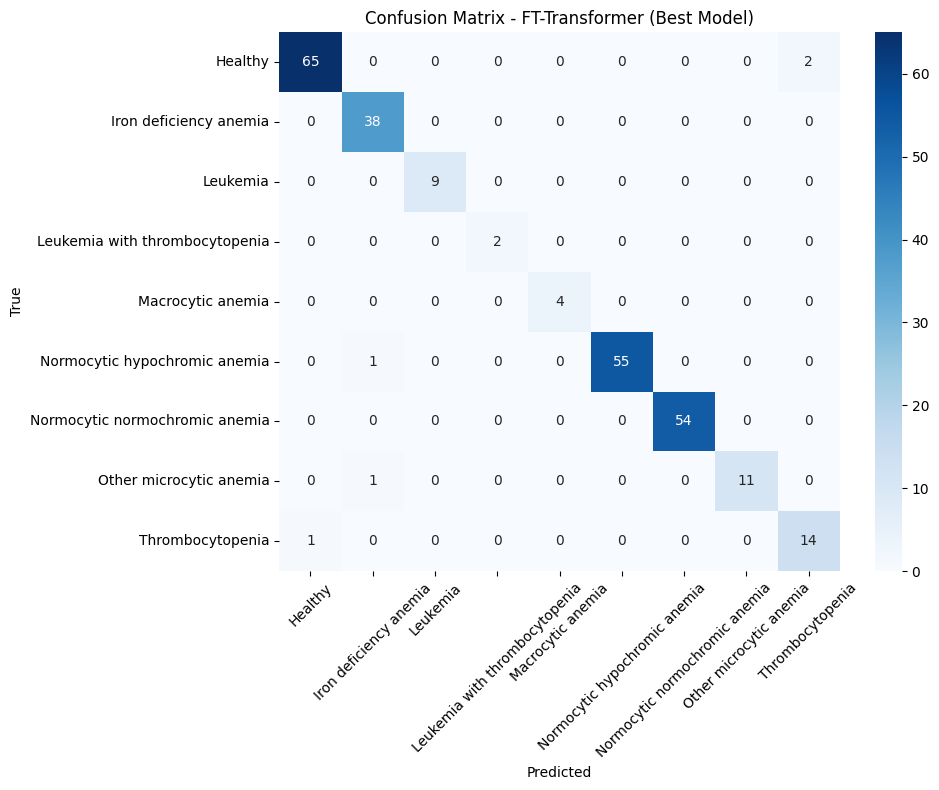

In [ ]:
# CELL 6 - Final Evaluation + Beautiful Confusion Matrix
model2.load_state_dict(torch.load("Model_2_-_FT-Transformer_best.pth"))
model2.eval()

all_preds = []
all_labels = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = torch.argmax(model2(xb), dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.numpy())

print(f"\nFINAL TEST ACCURACY: {accuracy_score(all_labels, all_preds)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - FT-Transformer (Best Model)")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# CELL 7 - Save Everything for Your Report
import pickle
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("Models, scaler, and encoder saved! Ready for deployment!")

Models, scaler, and encoder saved! Ready for deployment!
